# 03-1 k-최근접 이웃 회귀
- 다른 데이터가 있을 때, 농어의 **무게**를 k-최근접 이웃 회귀로 예측
- k-최근접 이웃 알고리즘과 달리 타깃은 샘플의 클래스가 아닌 **임의의 수치**
- feature: 농어의 길이
- target: 농어의 무게

In [3]:
# 농어 데이터 준비
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

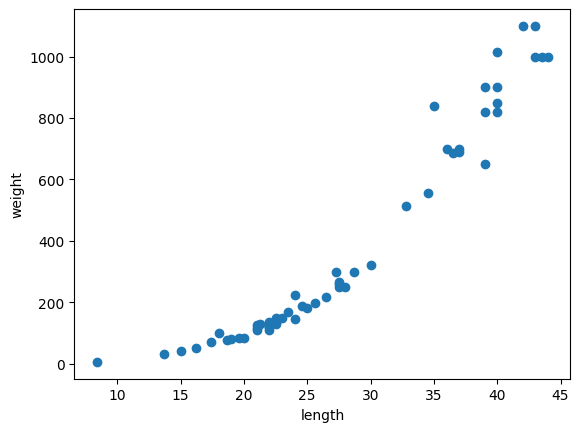

In [4]:
# 농어 데이터 산점도 확인
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [5]:
# 농어 데이터를 훈련 세트와 테스트 세트로 나누기

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

# input data를 2차원 배열로 변경
train_input = train_input.reshape(-1, 1) # shape: (42, 1)
test_input = test_input.reshape(-1, 1)   # shape: (14, 1)

In [6]:
# 회귀 모델 훈련

from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

# 테스트 점수 확인
print(knr.score(test_input, test_target))

0.992809406101064


In [8]:
# 타깃과 예측의 오차 계산하기

from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


In [9]:
# 과소 적합 해결 - 이웃의 개수를 5에서 3으로 줄이기(국지적인 패턴에 민감해짐)
knr.n_neighbors = 3

# 다시 훈련
knr.fit(train_input, train_target)
print('훈련 세트:', knr.score(train_input, train_target))
print('테스트 세트:', knr.score(test_input, test_target))

훈련 세트: 0.9804899950518966
테스트 세트: 0.9746459963987609
